# Probe Guidance Testing and Visualizations

Begin with visualizing some dataset examples

In [1]:
from pathlib import Path
import copy
import os

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
from torch.nn import functional as F
import torchvision.transforms as T
from scipy.spatial.transform import Rotation
from tqdm import tqdm

import sys
sys.path.append("/home/jack/code/vjepa2-probe-guidance/vjepa2")
print(sys.path)

['/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages', '/home/jack/code/vjepa2-probe-guidance/vjepa2/src', '/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages/rerun_sdk', '/home/jack/code/vjepa2-probe-guidance/vjepa2']


In [2]:
from app.vjepa_ll_probe_guidance.ll_probe_guidance import LLProbeGuidanceDataset, standardize_actions, standardize_states
from app.vjepa_ll_probe_guidance.utils import init_video_model
from app.vjepa_ll_probe_guidance.transforms import make_transforms
from utils.mpc_utils import (
    poses_to_diff
)

/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
# NOTE: the actions are in the probe's coordinate frame, while the states are 
# in the camera's coordinate frame. Does this have a negative impact on the model?
# Nonetheless, computing the new pose needs to account for this discrepancy.

# NOTE: state and action may be standardized, may need to account for this or rethink dataset/dataloader
# to not do standardization. Perhaps standardization should happen in training/testing and before passing to model
# forward functions (or within the forward functions themselves). doing it in dataset makes it hard to do visualizations.
# breaking standardization out can be good from a single-responsibility principle standpoint.

def compute_new_pose(pose, action):
    """
    :param pose: [B, T=1, 6] (x, y, z, rx, ry, rz in Euler angles) in camera frame
    :param action: [B, T=1, 6] (dx, dy, dz, drx, dry, drz) in local object frame
    :returns: [B, T=1, 6] updated pose in camera frame
    """
    device, dtype = pose.device, pose.dtype
    
    pose_np = pose[:, 0].detach().cpu().numpy()
    action_np = action[:, 0].detach().cpu().numpy()

    R_pose = Rotation.from_euler("xyz", pose_np[:, 3:6], degrees=True)
    R_pose_mat = R_pose.as_matrix()  # [B, 3, 3]

    # local action translation: [B, 3, 1] column vector
    local_dxyz = action_np[:, :3, None]
    
    global_dxyz = (R_pose_mat @ local_dxyz).squeeze(-1)  # [B, 3]
    new_xyz = pose_np[:, :3] + global_dxyz

    R_action = Rotation.from_euler("xyz", action_np[:, 3:6], degrees=True)
    R_new = R_pose * R_action

    new_angle = R_new.as_euler("xyz", degrees=True)  # [B, 3]

    new_pose = np.concatenate([new_xyz, new_angle], axis=-1)

    # Restore dimensions to [B, T=1, 6]
    return torch.from_numpy(new_pose).to(device=device, dtype=dtype)[:, None]

In [4]:
encoder, predictor = init_video_model(
        device="cuda:0",
        patch_size=16,
        max_num_frames=512,
        tubelet_size=2,
        model_name="vit_large",
        crop_size=256,
        pred_depth=12,
        pred_num_heads=12,
        pred_embed_dim=768,
        action_embed_dim=6,
        predictor_type="ac",
        pred_is_frame_causal=True,
        use_extrinsics=False,
        use_sdpa=True,
        use_rope=True
    )
target_encoder = copy.deepcopy(encoder)

encoder.eval()
predictor.eval()
target_encoder.eval()

print(encoder)
print(predictor)

VisionTransformer(
  (patch_embed): PatchEmbed3D(
    (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): RoPEAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): MLP(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
)
VisionTransfo

In [5]:
def load_state_dict_with_ddp_fix(model, state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        # Remove 'module.' prefix if it exists
        new_key = k.replace("module.", "")
        new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict, strict=True)
    return model

resume_path = os.path.join("/home/jack/code/vjepa2-probe-guidance/vjepa2/outputs/ll_probe_guidance_vitl_4", "best.pt")
if os.path.exists(resume_path):
    print(f"Loading checkpoint from {resume_path}")
    checkpoint = torch.load(resume_path, map_location=torch.device("cpu"))
    encoder = load_state_dict_with_ddp_fix(encoder, checkpoint["encoder"])
    predictor = load_state_dict_with_ddp_fix(predictor, checkpoint["predictor"])
    target_encoder = load_state_dict_with_ddp_fix(target_encoder, checkpoint["target_encoder"])
else:
    print(f"Checkpoint not found at {resume_path}")

Loading checkpoint from /home/jack/code/vjepa2-probe-guidance/vjepa2/outputs/ll_probe_guidance_vitl_4/best.pt


In [6]:
crop_size = 256
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)
transform = make_transforms(
    crop_size=crop_size,
)

In [7]:
# TODO: change frames per clip to 16? that would be 4 seconds of
T = 32
dataset = LLProbeGuidanceDataset(
    data_root="/home/jack/data/probe_guidance_dataset_june/test",
    frames_per_clip=T,
    frame_skip=1,
    frames_per_second=4,
    transform=transform,
    is_train=False,
)

loader = torch.utils.data.DataLoader(
    dataset,
    shuffle=False,
    batch_size=1,
    drop_last=True,
    pin_memory=False,
    num_workers=8,
)

Scanning 7 episodes for valid tracking clips...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 36.79it/s]

Retained 7 episodes.


In [8]:
def load_clips(sample):
    clips = sample[0].to("cuda:0", non_blocking=True)  # [B C T H W]
    actions = sample[1]  # [B T-1 6]
    states = sample[2]  # [B T 6]
    extrinsics = sample[3].to("cuda:0", dtype=torch.float, non_blocking=True)  # [B T 6]
    return (clips, actions, states, extrinsics)

sample = next(iter(loader))
clips, actions, states, _ = load_clips(sample)
for i in range(7):
    formatted_state = [f"{num:.5f}" for num in states[0][i]]
    formatted_action = [f"{num:.5f}" for num in actions[0][i]]
clips = clips[:, :, :T]
actions = actions[:, :T-1]
states = states[:, :T]
print(f"clips: {clips.shape}; states: {states.shape}; actions: {actions.shape}")

clips: torch.Size([1, 3, 32, 256, 256]); states: torch.Size([1, 32, 6]); actions: torch.Size([1, 31, 6])


### Visualize the Clip

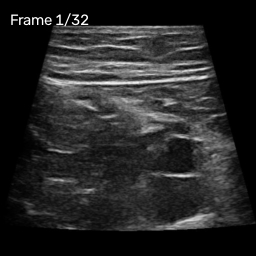

In [9]:
import io
import cv2
import imageio
import numpy as np
import torch
from IPython.display import Image, display

clip = clips[0] if clips.dim() == 5 else clips

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1).to(clip.device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1).to(clip.device)

clip_unnorm = (clip * std) + mean
frames = clip_unnorm.permute(1, 2, 3, 0)

frames_uint8 = (
    (frames * 255).clamp(0, 255).detach().cpu().numpy().astype(np.uint8)
)

T = frames_uint8.shape[0]
frames_with_text = []

for idx in range(T):
    frame = frames_uint8[idx].copy()
    text = f"Frame {idx + 1}/{T}"

    cv2.putText(
        frame,
        text,
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

    frames_with_text.append(frame)

buf = io.BytesIO()
imageio.mimsave(buf, frames_with_text, format="GIF", fps=4, loop=0)
display(Image(data=buf.getvalue()))

Let's calculate some descriptive statistics on the actions to get a sense of how much is happening in the clip.

In [10]:
action_mean = np.array([-2.7906366e-05,  5.4028669e-06,  6.0837847e-05, 
                        -1.7707590e-03, 2.4102912e-03, -3.7514704e-04], dtype=np.float32)
action_std = np.array([0.00498742, 0.00453256, 0.00675807, 
                       0.55955255, 0.43809873, 0.73082167], dtype=np.float32)

unstandardized_actions = (actions * action_std) + action_mean

act_data = unstandardized_actions.squeeze(0).cpu().numpy()
d_trans = act_data[:, :3]
d_rpy = act_data[:, 3:]

step_distances = np.linalg.norm(d_trans, axis=-1)
total_path_distance = np.sum(step_distances)

delta_rots = Rotation.from_euler('xyz', d_rpy, degrees=True)
step_rot_angles_rad = np.linalg.norm(delta_rots.as_rotvec(), axis=-1)
total_angular_distance_deg = np.degrees(np.sum(step_rot_angles_rad))

current_rot = Rotation.identity()
current_pos = np.zeros(3)

for i in range(len(act_data)):
    current_pos += current_rot.apply(d_trans[i])
    current_rot = current_rot * delta_rots[i]

net_displacement = np.linalg.norm(current_pos)
net_rotation_angle_deg = np.degrees(np.linalg.norm(current_rot.as_rotvec()))

print(f"Total Translation Path: {total_path_distance:.6f} meters")
print(f"Total Angular Motion:   {total_angular_distance_deg:.2f}°")
print(f"Net Translation Shift:  {net_displacement:.6f} meters")
print(f"Net Angular Shift:      {net_rotation_angle_deg:.2f}°")

# Straightness index
straightness_index = net_displacement / total_path_distance

# Translational Jerk
accel = np.diff(d_trans, axis=0)
jerk = np.diff(accel, axis=0)
mean_jerk_magnitude = np.mean(np.linalg.norm(jerk, axis=-1))

# Directional coherence
norms = np.linalg.norm(d_trans, axis=-1, keepdims=True)
normalized_steps = d_trans / (norms + 1e-8)  # avoid div by 0
cosine_sims = np.sum(normalized_steps[:-1] * normalized_steps[1:], axis=-1)
mean_directional_coherence = np.mean(cosine_sims)

# Angular jerk
rot_vecs = delta_rots.as_rotvec()  # axis-angle vectors
angular_jerk = np.diff(np.diff(rot_vecs, axis=0), axis=0)
mean_angular_jerk = np.mean(np.linalg.norm(angular_jerk, axis=-1))

print(f"Straightness Index:       {straightness_index:.4f}  (1.0 = perfect straight line)")
print(f"Directional Coherence:    {mean_directional_coherence:.4f}  (1.0 = smooth vector flow)")
print(f"Mean Linear Delta Jerk:   {mean_jerk_magnitude:.6f}")
print(f"Mean Angular Delta Jerk:  {np.degrees(mean_angular_jerk):.2f}°")

Total Translation Path: 0.002163 meters
Total Angular Motion:   31.15°
Net Translation Shift:  0.002071 meters
Net Angular Shift:      7.42°
Straightness Index:       0.9575  (1.0 = perfect straight line)
Directional Coherence:    0.9242  (1.0 = smooth vector flow)
Mean Linear Delta Jerk:   0.000050
Mean Angular Delta Jerk:  1.69°


/tmp/ipykernel_687240/2347146154.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  unstandardized_actions = (actions * action_std) + action_mean


In [11]:
def forward_target(c, normalize_reps=True):
    B, C, T, H, W = c.size()
    c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
    h = encoder(c)
    h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))
    return h

def step_predictor(z, a, s, normalize_reps=True):
    standardized_actions = standardize_actions(a).to("cuda:0", dtype=torch.float, non_blocking=True)
    standardized_states = standardize_states(s).to("cuda:0", dtype=torch.float, non_blocking=True)
    z = predictor(z, standardized_actions, standardized_states)[:, -tokens_per_frame:]
    if normalize_reps:
        z = F.layer_norm(z, (z.size(-1),))
    return z

def loss_fn(z, h):
    # NOTE: The caller is now responsible for making sure that the tokens in z and h align.
    # TODO: MAKE SURE THIS IS UPDATED IN ENERGY LANDSCAPE SECTION AND BEYOND (world model section)
    loss = torch.abs(z - h)  # [B, N, D]
    loss = torch.mean(loss, dim=[1, 2])
    return loss.tolist()

## Evaluate Rollout Performance
A natural question to have about the JEPA predictor/world model is how does it handle rollouts over a progressively longer horizon. In other words, can the predictor reliably determine the correct state of the world 1 step ahead? 2 steps ahead? 3 steps ahead? etc. Or does its predictions of the future states steadily (or quickly) degrade? Assuming degradation happens as rollouts occur over longer horizons, what does the degradation look like? Does it degrade linearly? Exponentially? Randomly? Is this degradation pattern consistent across samples within a dataset? Is it consistent across datasets? We are currently confined to the ultrasound dataset in this case, but it would be interesting to analyze degradation patterns across datasets. Do datasets exhibit different degradation patterns? or is degradation consistent across datasets? In either case, it would be interesting to explore why.

/usr/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


loss_total=[0.45697641372680664]
z_rollout_cur.shape=torch.Size([1, 8192, 1024])
h_rollout.shape=torch.Size([1, 8192, 1024])


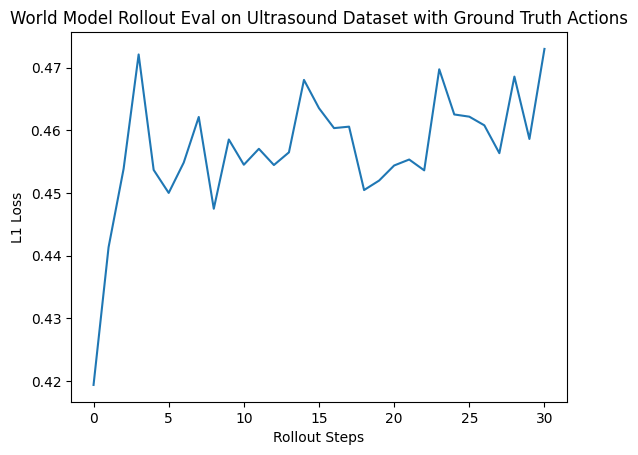

In [12]:
with torch.no_grad():
    h_rollout = forward_target(clips)
    
    # start with the representation of the first frame from the encoder
    z_rollout_cur = h_rollout[:, :tokens_per_frame]
    
    rollout_steps = T-1
    for n in range(rollout_steps):
        a_cur, s_cur, = actions[:, :n+1], states[:, :n+1]
        z_rollout_next = step_predictor(z_rollout_cur, a_cur, s_cur)[:, -tokens_per_frame:]
        z_rollout_cur = torch.cat([z_rollout_cur, z_rollout_next], dim=1)

loss_total = loss_fn(z_rollout_cur[:, tokens_per_frame:], h_rollout[:, tokens_per_frame:])
print(f"{loss_total=}")

print(f"{z_rollout_cur.shape=}")
print(f"{h_rollout.shape=}")

# Calculate L1 loss for each frame
frame_losses = []
for n in range(T):
    pred_frame = z_rollout_cur[:, tokens_per_frame * n:tokens_per_frame * (n+1)]
    gt_frame = h_rollout[:, tokens_per_frame * n:tokens_per_frame * (n+1)]
    cur_frame_loss = loss_fn(pred_frame, gt_frame)
    frame_losses.append(cur_frame_loss)
    #print(f"frame {n+1} loss: {cur_frame_loss} - {pred_frame.shape=} - {gt_frame.shape=}")

plt.plot(frame_losses[1:])

plt.title("World Model Rollout Eval on Ultrasound Dataset with Ground Truth Actions")
plt.xlabel("Rollout Steps")
plt.ylabel("L1 Loss")

plt.show()

## Energy Landscape Exploration

In [ ]:
def forward_action_grid(z, nsamples, grid_size=0.075, normalize_reps=True, action_repeat=1):

    def make_action_grid(grid_size=grid_size):
        action_samples = []
        for da in np.linspace(-grid_size, grid_size, nsamples):
            for db in np.linspace(-grid_size, grid_size, nsamples):
                for dc in np.linspace(-grid_size, grid_size, nsamples):
                    action_samples += [torch.tensor([da, db, dc, 0, 0, 0], device="cpu", dtype=z.dtype)]
        return torch.stack(action_samples, dim=0).unsqueeze(1)

    # Sample grid of actions
    action_samples = make_action_grid()
    print(f"Sampled grid of actions; num actions = {len(action_samples)}")

    # Context frame rep and context pose
    # NOTE: only uses the first frame/state
    z_hat = z[:, :tokens_per_frame].repeat(int(nsamples**3), 1, 1)  # [S, N, D] <- NOTE: N = tokens per frame??
    s_hat = states[:, :1].repeat((int(nsamples**3), 1, 1))  # [S, 1, 7]
    a_hat = action_samples  # [S, 1, 6]

    for _ in range(action_repeat):
        _z = step_predictor(z_hat, a_hat, s_hat)
        _s = compute_new_pose(s_hat[:, -1:], a_hat[:, -1:])
        z_hat = torch.cat([z_hat, _z], dim=1)
        s_hat = torch.cat([s_hat, _s], dim=1)
        a_hat = torch.cat([a_hat, action_samples], dim=1)

    print(f"z hat shape: {z_hat.shape}")
    print(f"s hat shape: {s_hat.shape}")
    print(f"a hat shape: {a_hat.shape}")
    return z_hat, s_hat, a_hat

In [18]:
# Compute energy for cartesian action grid of size (nsample x nsamples x nsamples)
# TODO: Make nsamples computation more memory efficient (don't try to fit everything into gpu memory at the same time?)
# TODO: Use `with torch.no_grad()`
nsamples = 5
#grid_size = 0.075
grid_size = 0.02
# NOTE: Action repeat MUST align with T = frames per clip
#action_repeat = T-1
action_repeat = 1
with torch.no_grad():
    h = forward_target(clips)
    print(f"h shape: {h.shape}")
    z_hat, s_hat, a_hat = forward_action_grid(h, nsamples=nsamples, grid_size=grid_size, action_repeat=action_repeat)
    loss = loss_fn(z_hat, h)  # jepa prediction loss

h shape: torch.Size([1, 4096, 1024])


NameError: name 'forward_action_grid' is not defined

In [ ]:
print(len(loss))

In [ ]:
# Plot the energy

plot_data = []
for b, v in enumerate(loss):
    # TODO: why are we summing here?
    plot_data.append((
        a_hat[b, :-1, 0].detach().cpu().sum(),
        a_hat[b, :-1, 1].detach().cpu().sum(),
        a_hat[b, :-1, 2].detach().cpu().sum(),
        v,
    ))

delta_x = [d[0] for d in plot_data]
delta_y = [d[1] for d in plot_data]
delta_z = [d[2] for d in plot_data]
energy = [d[3] for d in plot_data]

gt_x = actions[0, T-2, 0]
gt_y = actions[0, T-2, 1]
gt_z = actions[0, T-2, 2]

# Create the 2D histogram
heatmap, xedges, yedges = np.histogram2d(delta_x, delta_z, weights=energy, bins=nsamples)

# Set axis labels
plt.xlabel("Action Delta x")
plt.ylabel("Action Delta z")
plt.title(f"Energy Landscape")

# Display the heatmap
print(f"Ground truth action (x,y,z) = ({gt_x:.5f},{gt_y:.5f},{gt_z:.5f})")
_ = plt.imshow(heatmap.T, origin="lower", extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis")
_ = plt.colorbar()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy.interpolate import griddata
pio.renderers.default = "iframe"

# Convert PyTorch CUDA tensors to CPU floats
delta_x = [d[0].detach().cpu().item() if hasattr(d[0], 'detach') else d[0] for d in plot_data]
delta_y = [d[1].detach().cpu().item() if hasattr(d[1], 'detach') else d[1] for d in plot_data]
delta_z = [d[2].detach().cpu().item() if hasattr(d[2], 'detach') else d[2] for d in plot_data]
energy  = [d[3].detach().cpu().item() if hasattr(d[3], 'detach') else d[3] for d in plot_data]

gt_x = actions[0, T-2, 0].detach().cpu().item()
gt_y = actions[0, T-2, 1].detach().cpu().item()
gt_z = actions[0, T-2, 2].detach().cpu().item()

fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{'type': 'scene'}, {'type': 'scene'}],
        [{'type': 'scene'}, {'type': 'scene'}]
    ],
    subplot_titles=(
        "Energy Surface (XY Plane)",
        "Energy Surface (XZ Plane)",
        "Energy Surface (YZ Plane)",
        "Full 3D Spatial Scatter"
    ),
    horizontal_spacing=0.03,
    vertical_spacing=0.05
)

plane_pairs = [
    (delta_x, delta_y, "Delta X", "Delta Y", gt_x, gt_y, (1, 1)),
    (delta_x, delta_z, "Delta X", "Delta Z", gt_x, gt_z, (1, 2)),
    (delta_y, delta_z, "Delta Y", "Delta Z", gt_y, gt_z, (2, 1)),
]

min_e = float(np.min(energy))

for d1, d2, lbl1, lbl2, gt1, gt2, (row, col) in plane_pairs:
    # 1. Create a clean 50x50 interpolation grid over the data range
    xi = np.linspace(min(d1), max(d1), 50)
    yi = np.linspace(min(d2), max(d2), 50)
    XI, YI = np.meshgrid(xi, yi)

    # 2. Smoothly interpolate energy across the grid (linear avoids spikes & empty zeros)
    ZI = griddata((d1, d2), energy, (XI, YI), method='linear')
    
    # Fill remaining border NaNs with nearest neighbor
    nan_mask = np.isnan(ZI)
    if np.any(nan_mask):
        ZI_nearest = griddata((d1, d2), energy, (XI, YI), method='nearest')
        ZI[nan_mask] = ZI_nearest[nan_mask]

    # 3. Add smooth surface
    fig.add_trace(
        go.Surface(
            x=xi, y=yi, z=ZI,
            colorscale='Viridis',
            showscale=False,
            hovertemplate=f"{lbl1}: %{{x:.2f}}<br>{lbl2}: %{{y:.2f}}<br>Energy: %{{z:.2f}}<extra></extra>"
        ),
        row=row, col=col
    )

    # Add Ground Truth point
    fig.add_trace(
        go.Scatter3d(
            x=[gt1], y=[gt2], z=[min_e],
            mode='markers',
            marker=dict(size=8, color='red', symbol='diamond'),
            name='Ground Truth',
            showlegend=(row == 1 and col == 1)
        ),
        row=row, col=col
    )

# Panel 4: Full Spatial Scatter
fig.add_trace(
    go.Scatter3d(
        x=delta_x, y=delta_y, z=delta_z,
        mode='markers',
        marker=dict(
            size=4,
            color=energy,
            colorscale='Viridis',
            opacity=0.7,
            colorbar=dict(title="Energy", len=0.8, x=1.02)
        ),
        hovertemplate="ΔX: %{x:.2f}<br>ΔY: %{y:.2f}<br>ΔZ: %{z:.2f}<br>Energy: %{marker.color:.2f}<extra></extra>",
        name="Samples"
    ),
    row=2, col=2
)

fig.add_trace(
    go.Scatter3d(
        x=[gt_x], y=[gt_y], z=[gt_z],
        mode='markers',
        marker=dict(size=10, color='red', symbol='diamond'),
        name='Ground Truth Target'
    ),
    row=2, col=2
)

scenes = ['scene', 'scene2', 'scene3', 'scene4']
axis_labels = [
    ("Delta X", "Delta Y", "Energy"),
    ("Delta X", "Delta Z", "Energy"),
    ("Delta Y", "Delta Z", "Energy"),
    ("Delta X", "Delta Y", "Delta Z")
]

for scene_name, (x_lbl, y_lbl, z_lbl) in zip(scenes, axis_labels):
    fig.update_layout({
        scene_name: dict(
            xaxis_title=x_lbl,
            yaxis_title=y_lbl,
            zaxis_title=z_lbl,
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        )
    })

fig.update_layout(
    height=900,
    width=1100,
    title_text="Interactive Energy Landscape Analysis",
    template="plotly_white"
)

fig.show()

## World Modeling for Probe Guidance

In [ ]:
def l1(a, b):
    return torch.mean(torch.abs(a - b), dim=-1)


def round_small_elements(tensor, threshold):
    mask = torch.abs(tensor) < threshold
    new_tensor = tensor.clone()
    new_tensor[mask] = 0
    return new_tensor


def cem(
    context_frame,
    context_pose,
    goal_frame,
    world_model,
    rollout=1,
    cem_steps=100,
    momentum_mean=0.25,
    momentum_std=0.95,
    samples=100,
    topk=10,
    verbose=False,
    maxnorm=0.05,
    axis={},
    objective=l1,
):
    """
    :param context_frame: [B=1, T=1, HW, D]
    :param goal_frame: [B=1, T=1, HW, D]
    :param world_model: f(context_frame, action) -> next_frame [B, 1, HW, D]
    :return: [B=1, rollout, 7] an action trajectory over rollout horizon

    Cross-Entropy Method
    -----------------------
    1. for rollout horizon:
    1.1. sample several actions
    1.2. compute next states using WM
    3. compute similarity of final states to goal_frames
    4. select topk samples and update mean and std using topk action trajs
    5. choose final action to be mean of distribution
    """
    context_frame = context_frame.repeat(samples, 1, 1, 1)  # Reshape to [S, 1, HW, D]
    goal_frame = goal_frame.repeat(samples, 1, 1, 1)  # Reshape to [S, 1, HW, D]
    context_pose = standardize_states(context_pose).to("cuda:0", dtype=torch.float, non_blocking=True)
    context_pose = context_pose.repeat(samples, 1, 1)  # Reshape to [S, 1, 7]

    # Current estimate of the mean/std of distribution over action trajectories
    # Start with a normal distribution (mean=0 and std=1)
    mean = torch.zeros((rollout, 3), device=context_frame.device)
    std = torch.ones((rollout, 3), device=context_frame.device) * maxnorm

    # NOTE: What the hell is this for?
    for ax in axis.keys():
        mean[:, ax] = axis[ax]

    def sample_action_traj():
        """Sample several action trajectories"""
        action_traj, frame_traj, pose_traj = None, context_frame, context_pose

        for h in range(rollout):

            # -- sample new action
            # NOTE: why do * std[h] and + mean[h]? Does that effectively change the distribution?
            # NOTE: furthermore, torch.randn samples from a normal distribution...
            action_samples = torch.randn(samples, mean.size(1), device=mean.device) * std[h] + mean[h]
            action_samples[:, :3] = torch.clip(action_samples[:, :3], min=-maxnorm, max=maxnorm)

            # NOTE: same here, what is axis doing?
            for ax in axis.keys():
                action_samples[:, ax] = axis[ax]

                
            action_samples = torch.cat(
                [
                    action_samples[:, :3],
                    # NOTE: This is ignoring rotation from my understanding, undo this???
                    torch.zeros((len(action_samples), 3), device=mean.device),
                ],
                dim=-1,
            )[:, None]

            action_traj = (
                torch.cat([action_traj, action_samples], dim=1) if action_traj is not None else action_samples
            )

            # -- compute next state
            next_frame, next_pose = world_model(frame_traj, action_traj, pose_traj)
            frame_traj = torch.cat([frame_traj, next_frame], dim=1)
            pose_traj = torch.cat([pose_traj, next_pose], dim=1)

        return action_traj, frame_traj

    def select_topk_action_traj(final_state, goal_state, actions):
        """Get the topk action trajectories that bring us closest to goal"""
        print(f"final state shape: {final_state.shape}")
        sims = objective(final_state.flatten(1), goal_state.flatten(1))
        print(f"sims shape: {sims.shape}")
        indices = sims.topk(topk, largest=False).indices
        selected_actions = actions[indices]
        return selected_actions

    for step in tqdm(range(cem_steps), disable=True):
        action_traj, frame_traj = sample_action_traj()
        selected_actions = select_topk_action_traj(
            final_state=frame_traj[:, -1], goal_state=goal_frame, actions=action_traj
        )
        mean_selected_actions = selected_actions.mean(dim=0)
        std_selected_actions = selected_actions.std(dim=0)

        # -- Update new sampling mean and std based on the top-k samples
        mean = torch.cat(
            [
                mean_selected_actions[..., :3] * (1.0 - momentum_mean) + mean[..., :3] * momentum_mean,
            ],
            dim=-1,
        )
        std = torch.cat(
            [
                std_selected_actions[..., :3] * (1.0 - momentum_std) + std[..., :3] * momentum_std,
            ],
            dim=-1,
        )

        print(f"new mean: {mean.sum(dim=0)} {std.sum(dim=0)}")

    new_action = torch.cat(
        [
            mean[..., :3],
            torch.zeros((rollout, 3), device=mean.device),
        ],
        dim=-1,
    )[None, :]

    return new_action

class WorldModel(object):

    def __init__(
        self,
        encoder,
        predictor,
        tokens_per_frame,
        transform,
        mpc_args={
            "rollout": 2,
            "samples": 400,
            "topk": 10,
            "cem_steps": 10,
            "momentum_mean": 0.15,
            "momentum_std": 0.15,
            "maxnorm": 0.05,
            "verbose": True,
        },
        normalize_reps=True,
        device="cuda:0",
    ):
        super().__init__()
        self.encoder = encoder
        self.predictor = predictor
        self.normalize_reps = normalize_reps
        self.transform = transform
        self.tokens_per_frame = tokens_per_frame
        self.device = device
        self.mpc_args = mpc_args

    def encode(self, image):
        clip = np.expand_dims(image, axis=0)
        clip = self.transform(clip)[None, :]
        B, C, T, H, W = clip.size()
        clip = clip.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
        clip = clip.to(self.device, non_blocking=True)
        h = self.encoder(clip)
        h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
        if self.normalize_reps:
            h = F.layer_norm(h, (h.size(-1),))
        return h

    def infer_next_action(self, rep, pose, goal_rep, close_gripper=None):

        def step_predictor(reps, actions, poses):
            B, T, N_T, D = reps.size()
            reps = reps.flatten(1, 2)
            next_rep = self.predictor(reps, actions, poses)[:, -self.tokens_per_frame :]
            if self.normalize_reps:
                next_rep = F.layer_norm(next_rep, (next_rep.size(-1),))
            next_rep = next_rep.view(B, 1, N_T, D)
            next_pose = compute_new_pose(poses[:, -1:], actions[:, -1:])
            return next_rep, next_pose

        mpc_action = cem(
            context_frame=rep,
            context_pose=pose,
            goal_frame=goal_rep,
            world_model=step_predictor,
            **self.mpc_args,
        )[0]

        return mpc_action

### Model Predictive Control
VJEPA2 uses model predictive control (MPC) to perform tasks like controlling a robot arm to accomplish some goal. The "predictor" that we trained is used to understand how actions affect the state of the world. Then, the cross entropy method (CEM) is used to do "optimization", i.e. it will find a set of actions that minimize error/costs. The error in this case would be, "does the VJEPA2 AC predictor think that this action will reduce the L1 distance to the goal state"?. Then it does "receding horizon" control by simply taking the first action in the action trajectory that CEM found.

In [ ]:
# Compute the optimal action using MPC
world_model = WorldModel(
    encoder=encoder,
    predictor=predictor,
    tokens_per_frame=tokens_per_frame,
    transform=transform,
    # Doing very few CEM iterations with very few samples just to run efficiently on CPU...
    # ... increase cem_steps and samples for more accurate optimization of energy landscape
    mpc_args={
        "rollout": 2,
        "samples": 25,
        "topk": 10,
        "cem_steps": 20,
        "momentum_mean": 0.15,
        "momentum_std": 0.75,
        "maxnorm": 0.075,
        "verbose": True
    },
    normalize_reps=True,
    device="cpu"
)

with torch.no_grad():
    h = forward_target(clips)
    z_n, z_goal = h[:, :tokens_per_frame], h[:, -tokens_per_frame:]
    s_n = states[:, :1]
    print(f"Starting planning using Cross-Entropy Method...")
    wm_actions = world_model.infer_next_action(z_n, s_n, z_goal).cpu().numpy()

print(f"Actions returned by planning with CEM (x,y,z) = ({wm_actions[0, 0]:.5f}, {wm_actions[0, 1]:.5f}, {wm_actions[0, 2]:.5f})")
print(f"Ground truth actions (x,y,z) = ({actions[0, 0, 0]:.5f}, {actions[0, 0, 1]:.5f}, {actions[0, 0, 2]:.5f})")